# 6.19 - CertCF Merged Polytope Certification Diagnostics

This notebook tests a simple version of the **merged-polytope** idea on the same 2D Gaussian-mixture setting as `6.16`.

Goal:
- select a small local cluster of same-class certified polytopes
- wrap them with a single convex hull
- run a **fresh certification pass** on a bounding box around that hull
- certify the wrapped convex region by minimizing the affine lower bound over the hull vertices

If this succeeds, the wrapped polytope gives us:
- one query object instead of `N` local polytopes
- area greater than or equal to the original union
- a lower geometric distance to queries than the original union (because the hull contains it)


In [1]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from matplotlib.colors import ListedColormap
from shapely.geometry import Point
from shapely.ops import unary_union
from torch.utils.data import TensorDataset

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from auto_LiRPA import BoundedModule, BoundedTensor, PerturbationLpNorm
from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from certcf.certification.wrapping import WrappedModel
from certcf.geometry.polytopes import make_polygon
from models.classifiers import SimpleClassifier

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.title_fontsize': 9,
    'figure.titlesize': 12,
})

torch.set_grad_enabled(True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print({'device': str(DEVICE), 'seed': SEED})


{'device': 'cuda', 'seed': 42}


In [2]:
DATASET_CFG = {
    'n_train_per_component': 180,
    'n_test_per_component': 60,
    'class_0': [
        {'mean': (-2.8,  1.8), 'cov': ((0.55,  0.25), (0.25, 0.35))},
        {'mean': ( 0.0, -1.6), 'cov': ((0.45, -0.18), (-0.18, 0.40))},
        {'mean': ( 2.8,  1.6), 'cov': ((0.60,  0.22), (0.22, 0.35))},
    ],
    'class_1': [
        {'mean': (-1.4, -0.2), 'cov': ((0.50, -0.20), (-0.20, 0.45))},
        {'mean': ( 1.5,  0.1), 'cov': ((0.50,  0.18), (0.18, 0.45))},
    ],
}


def _sample_components(components, n_per_component, label, rng):
    xs = []
    ys = []
    for comp in components:
        x = rng.multivariate_normal(mean=np.asarray(comp['mean']), cov=np.asarray(comp['cov']), size=n_per_component)
        y = np.full(n_per_component, label, dtype=np.int64)
        xs.append(x.astype(np.float32))
        ys.append(y)
    return np.concatenate(xs, axis=0), np.concatenate(ys, axis=0)


def make_gaussian_mixture_dataset(cfg, seed=SEED):
    rng = np.random.default_rng(seed)
    x0_tr, y0_tr = _sample_components(cfg['class_0'], cfg['n_train_per_component'], 0, rng)
    x1_tr, y1_tr = _sample_components(cfg['class_1'], cfg['n_train_per_component'], 1, rng)
    x0_te, y0_te = _sample_components(cfg['class_0'], cfg['n_test_per_component'], 0, rng)
    x1_te, y1_te = _sample_components(cfg['class_1'], cfg['n_test_per_component'], 1, rng)

    x_train = np.concatenate([x0_tr, x1_tr], axis=0)
    y_train = np.concatenate([y0_tr, y1_tr], axis=0)
    x_test = np.concatenate([x0_te, x1_te], axis=0)
    y_test = np.concatenate([y0_te, y1_te], axis=0)

    train_perm = rng.permutation(len(x_train))
    test_perm = rng.permutation(len(x_test))
    return x_train[train_perm], y_train[train_perm], x_test[test_perm], y_test[test_perm]


X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE = make_gaussian_mixture_dataset(DATASET_CFG)
print({
    'train_shape': tuple(X_TRAIN.shape),
    'test_shape': tuple(X_TEST.shape),
    'train_class_counts': {int(c): int((Y_TRAIN_TRUE == c).sum()) for c in np.unique(Y_TRAIN_TRUE)},
    'test_class_counts': {int(c): int((Y_TEST_TRUE == c).sum()) for c in np.unique(Y_TEST_TRUE)},
})


{'train_shape': (900, 2), 'test_shape': (300, 2), 'train_class_counts': {0: 540, 1: 360}, 'test_class_counts': {0: 180, 1: 120}}


Epoch 1: Train Acc = 0.6000, Test Acc = 0.6000
Epoch 50: Train Acc = 0.8944, Test Acc = 0.8867
Epoch 100: Train Acc = 0.8989, Test Acc = 0.8800
Epoch 200: Train Acc = 0.9033, Test Acc = 0.8833
Epoch 400: Train Acc = 0.9067, Test Acc = 0.8767


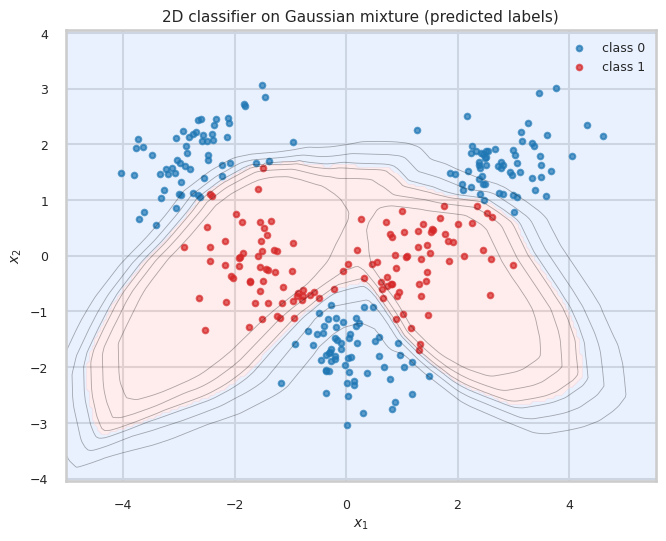

In [3]:
TRAIN_CFG = {
    'hidden_dims': (64, 32),
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 400,
    'batch_size': 128,
}


def train_classifier(x_train, y_train, x_test, y_test, cfg, device=DEVICE):
    model = SimpleClassifier(input_dim=2, hidden_dims=cfg['hidden_dims'], num_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss()

    x_train_t = torch.from_numpy(x_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)
    x_test_t = torch.from_numpy(x_test).float().to(device)
    y_test_t = torch.from_numpy(y_test).long().to(device)

    for epoch in range(cfg['epochs']):
        model.train()
        perm = torch.randperm(len(x_train_t), device=device)
        for start in range(0, len(x_train_t), cfg['batch_size']):
            idx = perm[start:start + cfg['batch_size']]
            logits = model(x_train_t[idx])
            loss = criterion(logits, y_train_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch in {0, 49, 99, 199, cfg['epochs'] - 1}:
            model.eval()
            with torch.no_grad():
                train_acc = (model(x_train_t).argmax(dim=1) == y_train_t).float().mean().item()
                test_acc = (model(x_test_t).argmax(dim=1) == y_test_t).float().mean().item()
            print(f'Epoch {epoch + 1}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}')

    model.eval()
    return model


@torch.no_grad()
def predict_np(model, x, device=DEVICE):
    x_t = torch.from_numpy(np.asarray(x, dtype=np.float32)).to(device)
    logits = model(x_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)
    return preds, probs


def plot_decision_boundary(model, x, y, title='Classifier decision boundary', grid_step=0.05):
    x_min, x_max = x[:, 0].min() - 1.0, x[:, 0].max() + 1.0
    y_min, y_max = x[:, 1].min() - 1.0, x[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step), np.arange(y_min, y_max, grid_step))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds, probs = predict_np(model, grid)
    zz = preds.reshape(xx.shape)
    conf = probs.max(axis=1).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = ListedColormap(['#cfe2ff', '#ffd6d6'])
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=0.45)
    ax.contour(xx, yy, conf, levels=[0.55, 0.70, 0.85], colors='k', linewidths=0.6, alpha=0.35)
    for cls, color in [(0, '#1f77b4'), (1, '#d62728')]:
        mask = y == cls
        ax.scatter(x[mask, 0], x[mask, 1], s=16, alpha=0.7, c=color, label=f'class {cls}')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(frameon=False)
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax


MODEL = train_classifier(X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE, TRAIN_CFG)
Y_TRAIN_PRED, _ = predict_np(MODEL, X_TRAIN)
Y_TEST_PRED, _ = predict_np(MODEL, X_TEST)
plot_decision_boundary(MODEL, X_TEST, Y_TEST_PRED, title='2D classifier on Gaussian mixture (predicted labels)')
plt.show()


## Build one local CertCF atlas and select a boundary-adjacent cluster

We build one atlas, then focus on a small local cluster of target-class certified polytopes near a boundary seed.

The merge experiment is local on purpose: we want to test whether wrapping a nearby family of certified polytopes can be re-certified as one larger convex object.


In [ ]:
MERGE_CFG = {
    'alpha': 0.45,
    'target_class': 1,
    'cell_size_scale': 2.0,
    'max_local_neighbors': 3,
    'proposal_grid_radius': 2,
    'proposal_top_center_neighbors': 12,
    'proposal_overlap_from_nearest_k': 24,
    'proposal_top_overlap_neighbors': 6,
    'proposal_top_triple_neighbors': 4,
    'proposal_max_triples_per_anchor': 6,
    'proposal_top_quad_neighbors': 4,
    'proposal_max_quads_per_anchor': 4,
    'top_pairs_to_certify': 12,
    'visualize_rank': 1,
    'iter_max_passes': 20,
    'iter_top_pairs_per_pass': 500,
    'iter_top_triples_per_pass': 300,
    'iter_top_quads_per_pass': 200,
    'iter_max_area_gain_ratio': 1e4,
}


def find_boundary_seed(model, x, y_pred, bisect_steps=60, tol=1e-6):
    idx0 = np.where(y_pred == 0)[0]
    idx1 = np.where(y_pred == 1)[0]
    x0 = x[idx0]
    x1 = x[idx1]
    dists = np.linalg.norm(x0[:, None, :] - x1[None, :, :], axis=2)
    pair = np.unravel_index(np.argmin(dists), dists.shape)
    left = x0[pair[0]].astype(np.float32).copy()
    right = x1[pair[1]].astype(np.float32).copy()
    x_t = torch.from_numpy(np.stack([left, right], axis=0)).to(DEVICE)
    logits = MODEL(x_t).detach().cpu().numpy()
    g_left = float(logits[0, 1] - logits[0, 0])
    g_right = float(logits[1, 1] - logits[1, 0])
    if np.sign(g_left) == np.sign(g_right):
        raise RuntimeError('Could not bracket a boundary crossing.')
    mid = 0.5 * (left + right)
    for _ in range(bisect_steps):
        mid = 0.5 * (left + right)
        g_mid = float((MODEL(torch.from_numpy(mid.reshape(1, -1)).to(DEVICE))[0, 1] - MODEL(torch.from_numpy(mid.reshape(1, -1)).to(DEVICE))[0, 0]).detach().cpu().item())
        if abs(g_mid) < tol or np.linalg.norm(right - left) < tol:
            break
        if np.sign(g_mid) == np.sign(g_left):
            left, g_left = mid, g_mid
        else:
            right, g_right = mid, g_mid
    return mid.astype(np.float32)


ds = TensorDataset(torch.from_numpy(X_TRAIN).float(), torch.from_numpy(Y_TRAIN_PRED).long())
atlas = CertCFAtlas(
    MODEL,
    ds,
    DEVICE,
    cnn=False,
    norm=1,
    distance_norm=1,
    lirpa_method='backward',
    eps_strategy=NearestOppositeClassClearanceStrategy(alpha=MERGE_CFG['alpha']),
    batch_size=256,
    default_query_method='nearest_anchor',
    solver_maxiter=500,
)
atlas.build(build_unions=False, verbose=True)

boundary_seed = find_boundary_seed(MODEL, X_TRAIN, Y_TRAIN_PRED)
bd = atlas.bounds[MERGE_CFG['target_class']]

target_polys = []
for idx in range(len(bd['X'])):
    poly = make_polygon(
        bd['lA'][idx],
        bd['lbias'][idx],
        bd['X'][idx],
        float(bd['eps'][idx]),
        norm=atlas.norm,
    )
    if poly is None or poly.is_empty:
        continue
    target_polys.append({
        'idx': int(idx),
        'center': bd['X'][idx].astype(np.float32),
        'eps': float(bd['eps'][idx]),
        'poly': poly,
    })

target_centers = np.stack([entry['center'] for entry in target_polys], axis=0)
target_seed_dists = np.linalg.norm(target_centers - boundary_seed[None, :], axis=1)
finite_eps = np.asarray([entry['eps'] for entry in target_polys], dtype=np.float64)
cell_size = float(np.median(finite_eps[finite_eps > 0])) * float(MERGE_CFG['cell_size_scale'])
cell_size = max(cell_size, 1e-3)

grid = defaultdict(list)
for local_idx, entry in enumerate(target_polys):
    cell = tuple(np.floor(entry['center'] / cell_size).astype(int))
    grid[cell].append(local_idx)

pair_candidates = {}
seen_pairs = set()
for i, entry in enumerate(target_polys):
    cell = tuple(np.floor(entry['center'] / cell_size).astype(int))
    local_pool = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            local_pool.extend(grid.get((cell[0] + dx, cell[1] + dy), []))
    local_pool = [j for j in local_pool if j != i]
    if not local_pool:
        continue
    local_pool = sorted(local_pool, key=lambda j: float(np.linalg.norm(target_polys[j]['center'] - entry['center'])))
    for j in local_pool[:MERGE_CFG['max_local_neighbors']]:
        pair = tuple(sorted((i, j)))
        if pair in seen_pairs:
            continue
        seen_pairs.add(pair)
        geoms = [target_polys[pair[0]]['poly'], target_polys[pair[1]]['poly']]
        union_geom = unary_union(geoms)
        hull_geom = union_geom.convex_hull
        pair_key = f"{target_polys[pair[0]]['idx']}-{target_polys[pair[1]]['idx']}"
        center_dist = float(np.linalg.norm(target_polys[pair[0]]['center'] - target_polys[pair[1]]['center']))
        pair_candidates[pair_key] = {
            'pair_key': pair_key,
            'subset': [target_polys[pair[0]], target_polys[pair[1]]],
            'union': union_geom,
            'hull': hull_geom,
            'center_dist': center_dist,
            'seed_dist_mean': float(0.5 * (target_seed_dists[pair[0]] + target_seed_dists[pair[1]])),
            'union_area': float(union_geom.area),
            'hull_area': float(hull_geom.area),
            'area_gain_abs': float(hull_geom.area - union_geom.area),
            'area_gain_ratio': float(hull_geom.area / union_geom.area) if union_geom.area > 0 else np.nan,
            'intersection_area': float(target_polys[pair[0]]['poly'].intersection(target_polys[pair[1]]['poly']).area),
        }

PAIR_CANDIDATES_DF = pd.DataFrame(pair_candidates.values()).sort_values(
    ['area_gain_ratio', 'center_dist', 'seed_dist_mean'],
    ascending=[True, True, True],
).reset_index(drop=True)
if not PAIR_CANDIDATES_DF.empty:
    PAIR_CANDIDATES_DF['proposal_sources'] = 'grid_local_knn'
    PAIR_CANDIDATES_DF['proposal_source_count'] = 1
else:
    PAIR_CANDIDATES_DF = PAIR_CANDIDATES_DF.assign(
        proposal_sources=pd.Series(dtype='object'),
        proposal_source_count=pd.Series(dtype='int64'),
    )

print({
    'boundary_seed': boundary_seed.tolist(),
    'target_polygons': len(target_polys),
    'grid_cell_size': cell_size,
    'local_pair_candidates': int(len(PAIR_CANDIDATES_DF)),
    'multi_source_pair_candidates': int((PAIR_CANDIDATES_DF['proposal_source_count'] > 1).sum()),
    'pairs_to_certify': int(min(MERGE_CFG['top_pairs_to_certify'], len(PAIR_CANDIDATES_DF))),
})
display(PAIR_CANDIDATES_DF.head(MERGE_CFG['top_pairs_to_certify']))





Building certified atlas (eps in [0.008518, 1.546] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.24s/it]

  Building BVH spatial indices...
    Class 0: 552 polytopes, tree depth 11
    Class 1: 348 polytopes, tree depth 10
Done! Total: 900 polytopes across 2 classes
{'boundary_seed': [2.8194897174835205, 0.7765331268310547], 'target_polygons': 348, 'grid_cell_size': 0.8892688740044832, 'local_pair_candidates': 659, 'multi_source_pair_candidates': 0, 'pairs_to_certify': 12}


,pair_key,subset,union,hull,center_dist,seed_dist_mean,union_area,hull_area,area_gain_abs,area_gain_ratio,intersection_area,proposal_sources,proposal_source_count
0,106-134,"[{'idx': 106, 'center': [-1.0354229, -0.258912...",POLYGON ((-1.035422921180725 0.211237557232379...,POLYGON ((-1.039694905281067 -0.73040454238653...,0.004400,3.993480,0.448362,0.448368,0.000006,1.000013,0.440319,grid_local_knn,1
1,42-168,"[{'idx': 42, 'center': [-1.8549635, -0.3091527...",POLYGON ((-1.0607374489307402 -0.3326776027679...,POLYGON ((-1.8759135007858276 -1.1478536546230...,0.031501,4.811759,1.369239,1.369296,0.000057,1.000041,1.292590,grid_local_knn,1
2,177-182,"[{'idx': 177, 'center': [2.261034, 0.003537653...",POLYGON ((2.7728499610209836 -0.00641715945675...,POLYGON ((2.261597156524658 -0.517669963953085...,0.009971,0.957502,0.528035,0.528073,0.000038,1.000072,0.507848,grid_local_knn,1
3,149-180,"[{'idx': 149, 'center': [-1.6026479, -0.126604...",POLYGON ((-1.6026479005813599 -0.9115441069006...,POLYGON ((-1.6026479005813599 -0.9115441069006...,0.035892,4.497598,1.272127,1.272246,0.000119,1.000093,1.185642,grid_local_knn,1
4,42-110,"[{'idx': 42, 'center': [-1.8549635, -0.3091527...",POLYGON ((-1.924373745918274 -1.19343349337577...,POLYGON ((-1.924373745918274 -1.19343349337577...,0.096297,4.840358,1.447989,1.448169,0.000181,1.000125,1.221536,grid_local_knn,1
5,9-166,"[{'idx': 9, 'center': [1.5628549, -0.003199058...",POLYGON ((2.125854669918772 -0.003199058352038...,POLYGON ((1.5628548860549927 -0.56619884221581...,0.016215,1.472873,0.643011,0.643094,0.000084,1.000130,0.608360,grid_local_knn,1
6,157-215,"[{'idx': 157, 'center': [1.8560374, -0.0884288...",POLYGON ((2.439605050906539 -0.105466417968273...,POLYGON ((1.8656957149505613 -0.67937575392425...,0.019585,1.296926,0.674350,0.674443,0.000093,1.000138,0.635537,grid_local_knn,1
7,110-168,"[{'idx': 110, 'center': [-1.9243737, -0.375900...",POLYGON ((-1.924373745918274 -1.19343349337577...,POLYGON ((-1.924373745918274 -1.19343349337577...,0.064936,4.853240,1.411756,1.411993,0.000237,1.000168,1.253988,grid_local_knn,1
8,114-266,"[{'idx': 114, 'center': [-1.834773, 0.05651188...",POLYGON ((-1.0950134217739105 0.05651187896728...,POLYGON ((-1.8347729444503782 -0.6832476437091...,0.023306,4.704020,1.117344,1.117532,0.000188,1.000168,1.053228,grid_local_knn,1
9,195-277,"[{'idx': 195, 'center': [2.1228855, -0.5051473...",POLYGON ((2.1228854656219482 -1.26600769162178...,POLYGON ((2.1228854656219482 -1.26600769162178...,0.027315,1.449576,1.175045,1.175262,0.000218,1.000185,1.095640,grid_local_knn,1


## Fresh certification of locally chosen wrapped pairs

We keep the candidate search intentionally simple:
1. build a coarse spatial grid over target-class anchors
2. for each anchor, inspect only a tiny local neighborhood
3. form same-class pairs and rank them by how little extra area the convex hull adds
4. certify only the best-ranked pairs with a fresh LiRPA pass

This is not globally optimal, but it is close in spirit to a linear-time local merge heuristic.


In [5]:
def run_lirpa_box_lower_bound(model, target_label, x_L, x_U, device=DEVICE, lirpa_method='backward'):
    x_L = np.asarray(x_L, dtype=np.float32).reshape(1, -1)
    x_U = np.asarray(x_U, dtype=np.float32).reshape(1, -1)
    x_center = 0.5 * (x_L + x_U)

    wrapped = WrappedModel(model, label=int(target_label), device=device, n_labels=2).to(device).to(torch.float32)
    wrapped.eval()

    x_center_t = torch.from_numpy(x_center).to(device)
    x_L_t = torch.from_numpy(x_L).to(device)
    x_U_t = torch.from_numpy(x_U).to(device)
    ptb = PerturbationLpNorm(norm=np.inf, x_L=x_L_t, x_U=x_U_t)
    X_bounded = BoundedTensor(x_center_t, ptb)

    bounded_model = BoundedModule(wrapped, X_bounded)
    _ = bounded_model(X_bounded)

    needed_A = defaultdict(set)
    needed_A[bounded_model.output_name[0]].add(bounded_model.input_name[0])
    _, _, A_dict = bounded_model.compute_bounds(
        x=(X_bounded,),
        method=lirpa_method,
        return_A=True,
        needed_A_dict=needed_A,
    )

    A = A_dict[bounded_model.output_name[0]][bounded_model.input_name[0]]
    lA = A['lA'].detach().cpu().numpy().reshape(-1, x_center.shape[1])
    lbias = A['lbias'].detach().cpu().numpy().reshape(-1)
    return lA[0].astype(np.float64), float(lbias[0])


def polygon_vertices(poly):
    coords = np.asarray(poly.exterior.coords[:-1], dtype=np.float64)
    return coords


def certify_convex_polygon(model, target_label, poly, padding=0.02):
    minx, miny, maxx, maxy = poly.bounds
    x_L = np.array([minx - padding, miny - padding], dtype=np.float32)
    x_U = np.array([maxx + padding, maxy + padding], dtype=np.float32)
    c, d = run_lirpa_box_lower_bound(model, target_label, x_L=x_L, x_U=x_U)
    verts = polygon_vertices(poly)
    values = verts @ c + d
    min_value = float(values.min())
    return {
        'certified': bool(min_value > 0.0),
        'min_affine_margin': min_value,
        'affine_c': c,
        'affine_d': float(d),
        'bbox_area': float((x_U[0] - x_L[0]) * (x_U[1] - x_L[1])),
        'x_L': x_L,
        'x_U': x_U,
    }


merge_rows = []
merge_objects = {}
for rank, row in PAIR_CANDIDATES_DF.head(MERGE_CFG['top_pairs_to_certify']).iterrows():
    pair_key = row['pair_key']
    pair_obj = pair_candidates[pair_key]
    cert = certify_convex_polygon(MODEL, MERGE_CFG['target_class'], pair_obj['hull'])
    merge_rows.append({
        'pair_rank': int(rank + 1),
        'pair_key': pair_key,
        'idx_a': int(pair_obj['subset'][0]['idx']),
        'idx_b': int(pair_obj['subset'][1]['idx']),
        'certified': bool(cert['certified']),
        'min_affine_margin': float(cert['min_affine_margin']),
        'center_dist': float(pair_obj['center_dist']),
        'seed_dist_mean': float(pair_obj['seed_dist_mean']),
        'intersection_area': float(pair_obj['intersection_area']),
        'union_area': float(pair_obj['union_area']),
        'hull_area': float(pair_obj['hull_area']),
        'area_gain_abs': float(pair_obj['area_gain_abs']),
        'area_gain_ratio': float(pair_obj['area_gain_ratio']),
        'bbox_area': float(cert['bbox_area']),
    })
    merge_objects[pair_key] = {
        **pair_obj,
        'cert': cert,
    }

MERGE_RESULTS_DF = pd.DataFrame(merge_rows).sort_values(
    ['certified', 'area_gain_ratio', 'center_dist'],
    ascending=[False, True, True],
).reset_index(drop=True)
display(MERGE_RESULTS_DF)


def build_local_merge_candidates_for_regions(regions, boundary_seed, cfg):
    if len(regions) < 2:
        return pd.DataFrame(), {}

    centers = np.stack([np.asarray(region['center'], dtype=np.float32) for region in regions], axis=0)
    seed_dists = np.linalg.norm(centers - boundary_seed[None, :], axis=1)
    finite_scales = np.asarray([max(float(np.sqrt(region['geom'].area)), 1e-6) for region in regions], dtype=np.float64)
    cell_size = float(np.median(finite_scales[finite_scales > 0])) * float(cfg['cell_size_scale'])
    cell_size = max(cell_size, 1e-3)

    grid = defaultdict(list)
    for local_idx, center in enumerate(centers):
        cell = tuple(np.floor(center / cell_size).astype(int))
        grid[cell].append(local_idx)

    diff = centers[:, None, :] - centers[None, :, :]
    center_dmat = np.linalg.norm(diff, axis=2)
    candidate_map = {}

    def register_subset(indices, source_tag):
        indices = tuple(sorted({int(idx) for idx in indices}))
        if len(indices) < 2:
            return
        candidate_key = '|'.join(regions[idx]['region_key'] for idx in indices)
        if candidate_key in candidate_map:
            candidate_map[candidate_key]['proposal_sources'].add(source_tag)
            return

        subset = [regions[idx] for idx in indices]
        geoms = [region['geom'] for region in subset]
        union_geom = unary_union(geoms)
        hull_geom = union_geom.convex_hull
        intersection_geom = geoms[0]
        for geom in geoms[1:]:
            intersection_geom = intersection_geom.intersection(geom)
        pairwise_distances = center_dmat[np.ix_(indices, indices)]

        candidate_map[candidate_key] = {
            'pair_key': candidate_key,
            'region_indices': indices,
            'subset': subset,
            'subset_size': int(len(indices)),
            'union': union_geom,
            'hull': hull_geom,
            'center_dist': float(pairwise_distances.max()),
            'seed_dist_mean': float(np.mean(seed_dists[list(indices)])),
            'union_area': float(union_geom.area),
            'hull_area': float(hull_geom.area),
            'area_gain_abs': float(hull_geom.area - union_geom.area),
            'area_gain_ratio': float(hull_geom.area / union_geom.area) if union_geom.area > 0 else np.nan,
            'intersection_area': float(intersection_geom.area),
            'member_count_before': int(sum(region['member_count'] for region in subset)),
            'proposal_sources': {source_tag},
        }

    for i, center in enumerate(centers):
        order = np.argsort(center_dmat[i])
        center_neighbors = [int(j) for j in order[1:1 + int(cfg['proposal_top_center_neighbors'])]]
        for j in center_neighbors:
            register_subset((i, j), 'global_center_knn')

        cell = tuple(np.floor(center / cell_size).astype(int))
        local_pool = []
        radius = int(cfg['proposal_grid_radius'])
        for dx in range(-radius, radius + 1):
            for dy in range(-radius, radius + 1):
                local_pool.extend(grid.get((cell[0] + dx, cell[1] + dy), []))
        local_pool = [int(j) for j in local_pool if j != i]
        local_pool = sorted(set(local_pool), key=lambda j: float(center_dmat[i, j]))
        for j in local_pool[:int(cfg['max_local_neighbors'])]:
            register_subset((i, j), 'grid_local_knn')

        overlap_pool = center_neighbors[:int(cfg['proposal_overlap_from_nearest_k'])]
        overlap_scored = []
        geom_i = regions[i]['geom']
        for j in overlap_pool:
            geom_j = regions[j]['geom']
            intersection_area = float(geom_i.intersection(geom_j).area)
            if intersection_area <= 0.0:
                continue
            union_area = float(geom_i.union(geom_j).area)
            overlap_ratio = intersection_area / union_area if union_area > 0 else 0.0
            overlap_scored.append((overlap_ratio, -float(center_dmat[i, j]), j))
        overlap_scored.sort(reverse=True)
        overlap_neighbors = [int(j) for _, _, j in overlap_scored[:int(cfg['proposal_top_overlap_neighbors'])]]
        for j in overlap_neighbors:
            register_subset((i, j), 'high_overlap')

        triple_pool = []
        for j in center_neighbors[:int(cfg['proposal_top_triple_neighbors'])]:
            triple_pool.append(int(j))
        for j in local_pool[:int(cfg['proposal_top_triple_neighbors'])]:
            triple_pool.append(int(j))
        for j in overlap_neighbors[:int(cfg['proposal_top_triple_neighbors'])]:
            triple_pool.append(int(j))
        triple_pool = sorted(set(j for j in triple_pool if j != i), key=lambda j: float(center_dmat[i, j]))

        triple_count = 0
        for pos_a, j in enumerate(triple_pool):
            for k in triple_pool[pos_a + 1:]:
                register_subset((i, j, k), 'local_triple')
                triple_count += 1
                if triple_count >= int(cfg['proposal_max_triples_per_anchor']):
                    break
            if triple_count >= int(cfg['proposal_max_triples_per_anchor']):
                break

        quad_pool = []
        for j in center_neighbors[:int(cfg['proposal_top_quad_neighbors'])]:
            quad_pool.append(int(j))
        for j in local_pool[:int(cfg['proposal_top_quad_neighbors'])]:
            quad_pool.append(int(j))
        for j in overlap_neighbors[:int(cfg['proposal_top_quad_neighbors'])]:
            quad_pool.append(int(j))
        quad_pool = sorted(set(j for j in quad_pool if j != i), key=lambda j: float(center_dmat[i, j]))

        quad_count = 0
        for pos_a, j in enumerate(quad_pool):
            for pos_b, k in enumerate(quad_pool[pos_a + 1:], start=pos_a + 1):
                for l in quad_pool[pos_b + 1:]:
                    register_subset((i, j, k, l), 'local_quad')
                    quad_count += 1
                    if quad_count >= int(cfg['proposal_max_quads_per_anchor']):
                        break
                if quad_count >= int(cfg['proposal_max_quads_per_anchor']):
                    break
            if quad_count >= int(cfg['proposal_max_quads_per_anchor']):
                break

    if not candidate_map:
        return pd.DataFrame(), {}

    candidate_df = pd.DataFrame(candidate_map.values())
    candidate_df['proposal_source_count'] = candidate_df['proposal_sources'].map(len)
    candidate_df['proposal_sources'] = candidate_df['proposal_sources'].map(lambda values: ','.join(sorted(values)))
    candidate_df = candidate_df.sort_values(
        ['subset_size', 'member_count_before', 'proposal_source_count', 'area_gain_ratio', 'intersection_area', 'center_dist', 'seed_dist_mean'],
        ascending=[False, False, False, True, False, True, True],
    ).reset_index(drop=True)
    return candidate_df, candidate_map


def run_iterative_local_merging(regions, boundary_seed, cfg):
    current_regions = [
        {
            **region,
            'center': np.asarray(region['center'], dtype=np.float32),
            'member_count': int(region['member_count']),
            'source_ids': list(region['source_ids']),
        }
        for region in regions
    ]
    pass_rows = []
    merge_rows = []

    for pass_idx in range(1, int(cfg['iter_max_passes']) + 1):
        candidate_df, candidate_map = build_local_merge_candidates_for_regions(current_regions, boundary_seed, cfg)
        if candidate_df.empty:
            pass_rows.append({
                'pass_idx': pass_idx,
                'regions_start': int(len(current_regions)),
                'candidate_pairs': 0,
                'pairs_tested': 0,
                'successful_merges': 0,
                'regions_end': int(len(current_regions)),
            })
            break

        shortlisted_pairs = candidate_df.loc[candidate_df['subset_size'] == 2].head(int(cfg['iter_top_pairs_per_pass']))
        shortlisted_triples = candidate_df.loc[candidate_df['subset_size'] == 3].head(int(cfg['iter_top_triples_per_pass']))
        shortlisted_quads = candidate_df.loc[candidate_df['subset_size'] == 4].head(int(cfg['iter_top_quads_per_pass']))
        shortlisted = pd.concat([shortlisted_pairs, shortlisted_triples, shortlisted_quads], ignore_index=True)
        if not shortlisted.empty:
            shortlisted = shortlisted.sort_values(
                ['subset_size', 'member_count_before', 'proposal_source_count', 'area_gain_ratio', 'intersection_area', 'center_dist'],
                ascending=[False, False, False, True, False, True],
            ).reset_index(drop=True)

        certified_candidates = []
        pairs_tested = 0
        for _, row in shortlisted.iterrows():
            if float(row['area_gain_ratio']) > float(cfg['iter_max_area_gain_ratio']):
                continue
            pairs_tested += 1
            candidate_obj = candidate_map[row['pair_key']]
            cert = certify_convex_polygon(MODEL, MERGE_CFG['target_class'], candidate_obj['hull'])
            if not cert['certified']:
                continue
            certified_candidates.append({
                **row.to_dict(),
                'cert': cert,
                'candidate_obj': candidate_obj,
            })

        certified_candidates = sorted(
            certified_candidates,
            key=lambda row: (
                -int(row['member_count_before']),
                -int(row['subset_size']),
                -int(row['proposal_source_count']),
                -float(row['cert']['min_affine_margin']),
                float(row['area_gain_ratio']),
                -float(row['intersection_area']),
                float(row['center_dist']),
            ),
        )

        used = set()
        next_regions = []
        successful_merges = 0
        for row in certified_candidates:
            candidate_obj = row['candidate_obj']
            region_indices = tuple(int(idx) for idx in candidate_obj['region_indices'])
            if any(idx in used for idx in region_indices):
                continue

            merged_source_ids = sorted({
                int(source_id)
                for subset_region in candidate_obj['subset']
                for source_id in subset_region['source_ids']
            })
            merged_region = {
                'region_key': f"pass{pass_idx}_merge{successful_merges + 1}",
                'center': np.asarray(candidate_obj['hull'].centroid.coords[0], dtype=np.float32),
                'geom': candidate_obj['hull'],
                'member_count': int(candidate_obj['member_count_before']),
                'source_ids': merged_source_ids,
                'cert': row['cert'],
            }
            next_regions.append(merged_region)
            used.update(region_indices)
            successful_merges += 1
            merge_rows.append({
                'pass_idx': pass_idx,
                'pair_key': row['pair_key'],
                'subset_size': int(row['subset_size']),
                'member_count_before': int(candidate_obj['member_count_before']),
                'proposal_source_count': int(row['proposal_source_count']),
                'proposal_sources': row['proposal_sources'],
                'area_gain_ratio': float(row['area_gain_ratio']),
                'center_dist': float(row['center_dist']),
                'intersection_area': float(row['intersection_area']),
                'union_area': float(candidate_obj['union_area']),
                'hull_area': float(candidate_obj['hull_area']),
                'min_affine_margin': float(row['cert']['min_affine_margin']),
            })

        for idx, region in enumerate(current_regions):
            if idx not in used:
                next_regions.append(region)

        pass_rows.append({
            'pass_idx': pass_idx,
            'regions_start': int(len(current_regions)),
            'candidate_pairs': int(len(candidate_df)),
            'pairs_tested': int(pairs_tested),
            'successful_merges': int(successful_merges),
            'regions_end': int(len(next_regions)),
        })

        current_regions = next_regions
        if successful_merges == 0:
            break

    return pd.DataFrame(pass_rows), pd.DataFrame(merge_rows), current_regions


INITIAL_REGIONS = [
    {
        'region_key': f"poly_{entry['idx']}",
        'center': entry['center'],
        'geom': entry['poly'],
        'member_count': 1,
        'source_ids': [int(entry['idx'])],
    }
    for entry in target_polys
]

SOURCE_POLY_BY_IDX = {int(entry['idx']): entry['poly'] for entry in target_polys}


def build_union_from_source_ids(source_ids):
    return unary_union([SOURCE_POLY_BY_IDX[int(idx)] for idx in source_ids])


ITER_PASSES_DF, ITER_MERGES_DF, ITER_FINAL_REGIONS = run_iterative_local_merging(INITIAL_REGIONS, boundary_seed, MERGE_CFG)
display(ITER_PASSES_DF)
if not ITER_MERGES_DF.empty:
    display(ITER_MERGES_DF.head(20))




,pair_rank,pair_key,idx_a,idx_b,certified,min_affine_margin,center_dist,seed_dist_mean,intersection_area,union_area,hull_area,area_gain_abs,area_gain_ratio,bbox_area
0,1,106-134,106,134,True,0.926125,0.004400,3.993480,0.440319,0.448362,0.448368,0.000006,1.000013,0.972255
1,3,177-182,177,182,True,1.207876,0.009971,0.957502,0.507848,0.528035,0.528073,0.000038,1.000072,1.134466
2,6,9-166,9,166,True,0.589162,0.016215,1.472873,0.608360,0.643011,0.643094,0.000084,1.000130,1.369100
3,7,157-215,157,215,True,1.285767,0.019585,1.296926,0.635537,0.674350,0.674443,0.000093,1.000138,1.434821
4,10,195-277,195,277,True,0.074392,0.027315,1.449576,1.095640,1.175045,1.175262,0.000218,1.000185,2.457052
5,11,39-227,39,227,True,0.803018,0.026938,1.349684,0.911570,0.978106,0.978319,0.000214,1.000218,2.052229
6,2,42-168,42,168,False,-0.810215,0.031501,4.811759,1.292590,1.369239,1.369296,0.000057,1.000041,2.868782
7,4,149-180,149,180,False,-0.757338,0.035892,4.497598,1.185642,1.272127,1.272246,0.000119,1.000093,2.666659
8,5,42-110,42,110,False,-1.076736,0.096297,4.840358,1.221536,1.447989,1.448169,0.000181,1.000125,3.034376
9,8,110-168,110,168,False,-0.949608,0.064936,4.853240,1.253988,1.411756,1.411993,0.000237,1.000168,2.953409


,pass_idx,regions_start,candidate_pairs,pairs_tested,successful_merges,regions_end
0,1,348,5609,1000,63,258
1,2,258,4340,1000,21,226
2,3,226,3738,1000,5,218
3,4,218,3610,1000,1,216
4,5,216,3591,1000,0,216


,pass_idx,pair_key,subset_size,member_count_before,proposal_source_count,proposal_sources,area_gain_ratio,center_dist,intersection_area,union_area,hull_area,min_affine_margin
0,1,poly_96|poly_146|poly_267|poly_302,4,4,1,local_quad,1.004819,0.140889,0.264748,0.504571,0.507003,1.148512
1,1,poly_19|poly_29|poly_44|poly_118,4,4,1,local_quad,1.007271,0.143037,0.160667,0.389445,0.392277,0.744069
2,1,poly_76|poly_174|poly_214|poly_330,4,4,1,local_quad,1.006044,0.206967,0.254371,0.661940,0.665941,0.638508
3,1,poly_38|poly_106|poly_134|poly_229,4,4,1,local_quad,1.004317,0.145379,0.388692,0.688290,0.691262,0.634687
4,1,poly_26|poly_69|poly_188|poly_208,4,4,1,local_quad,1.005358,0.193319,0.419219,0.839714,0.844213,0.424843
5,1,poly_62|poly_111|poly_183|poly_271,4,4,1,local_quad,1.007816,0.155526,0.353800,0.697329,0.702780,0.417300
6,1,poly_94|poly_179|poly_184|poly_290,4,4,1,local_quad,1.008258,0.191042,0.069114,0.237043,0.239001,0.354056
7,1,poly_72|poly_89|poly_159|poly_200,4,4,1,local_quad,1.007822,0.179636,0.121824,0.336638,0.339271,0.312873
8,1,poly_55|poly_112|poly_162|poly_291,4,4,1,local_quad,1.004925,0.153310,0.576340,0.938178,0.942798,0.277509
9,1,poly_39|poly_132|poly_227|poly_277,4,4,1,local_quad,1.003674,0.123766,0.808392,1.219413,1.223894,0.108964


In [6]:
VIS_RANK = int(MERGE_CFG.get('visualize_rank', 1))
VIS_ROW = MERGE_RESULTS_DF.iloc[min(max(VIS_RANK - 1, 0), len(MERGE_RESULTS_DF) - 1)]
VIS_KEY = VIS_ROW['pair_key']
VIS = merge_objects[VIS_KEY]

CERTIFIED_RESULTS_DF = MERGE_RESULTS_DF.loc[MERGE_RESULTS_DF['certified']].copy()
BEST_KEY = CERTIFIED_RESULTS_DF.iloc[0]['pair_key'] if not CERTIFIED_RESULTS_DF.empty else None
BEST = merge_objects[BEST_KEY] if BEST_KEY is not None else None

source_label = 1 - MERGE_CFG['target_class']
source_test_idx = np.where(Y_TEST_PRED == source_label)[0]
vis_probe_center = np.asarray(VIS['hull'].centroid.coords[0], dtype=np.float32)
source_test_order = np.argsort(np.linalg.norm(X_TEST[source_test_idx] - vis_probe_center[None, :], axis=1))
probe_idx = source_test_idx[source_test_order[:40]]

print({
    'visualized_pair_rank': int(VIS_ROW['pair_rank']),
    'visualized_pair_key': VIS_KEY,
    'visualized_certified': bool(VIS['cert']['certified']),
    'visualized_probe_center': vis_probe_center.tolist(),
    'visualized_center_dist': float(VIS['center_dist']),
    'visualized_intersection_area': float(VIS['intersection_area']),
    'visualized_min_affine_margin': float(VIS['cert']['min_affine_margin']),
    'visualized_union_area': float(VIS['union'].area),
    'visualized_hull_area': float(VIS['hull'].area),
    'visualized_speedup_proxy_qp_count': {'original': 2, 'merged': 1},
})

if not ITER_PASSES_DF.empty:
    print({
        'iter_regions_start': int(ITER_PASSES_DF.iloc[0]['regions_start']),
        'iter_regions_end': int(ITER_PASSES_DF.iloc[-1]['regions_end']),
        'iter_total_successful_merges': int(ITER_PASSES_DF['successful_merges'].sum()),
        'iter_passes_executed': int(len(ITER_PASSES_DF)),
    })

ITER_VIS_REGION = None
ITER_VIS_UNION = None
ITER_REGION_PROBE_DF = None
iter_probe_idx = probe_idx
iter_probe_center = vis_probe_center
iterative_regions = [region for region in ITER_FINAL_REGIONS if int(region['member_count']) > 1]
if iterative_regions:
    ITER_VIS_REGION = max(iterative_regions, key=lambda region: (int(region['member_count']), float(region['geom'].area)))
    ITER_VIS_UNION = build_union_from_source_ids(ITER_VIS_REGION['source_ids'])
    iter_probe_center = np.asarray(ITER_VIS_REGION['geom'].centroid.coords[0], dtype=np.float32)
    iter_source_test_order = np.argsort(np.linalg.norm(X_TEST[source_test_idx] - iter_probe_center[None, :], axis=1))
    iter_probe_idx = source_test_idx[iter_source_test_order[:40]]
    iter_probe_rows = []
    for idx in iter_probe_idx:
        point = Point(float(X_TEST[idx, 0]), float(X_TEST[idx, 1]))
        dist_union = float(ITER_VIS_UNION.distance(point))
        dist_region = float(ITER_VIS_REGION['geom'].distance(point))
        iter_probe_rows.append({
            'query_idx': int(idx),
            'dist_to_source_union': dist_union,
            'dist_to_iter_region': dist_region,
            'improvement': dist_union - dist_region,
        })
    ITER_REGION_PROBE_DF = pd.DataFrame(iter_probe_rows)
    print({
        'iter_visualized_region_key': ITER_VIS_REGION['region_key'],
        'iter_visualized_member_count': int(ITER_VIS_REGION['member_count']),
        'iter_visualized_source_count': int(len(ITER_VIS_REGION['source_ids'])),
        'iter_visualized_union_area': float(ITER_VIS_UNION.area),
        'iter_visualized_region_area': float(ITER_VIS_REGION['geom'].area),
        'iter_visualized_area_gain_ratio': float(ITER_VIS_REGION['geom'].area / ITER_VIS_UNION.area) if ITER_VIS_UNION.area > 0 else np.nan,
    })
    display(ITER_REGION_PROBE_DF.describe())

if BEST is None:
    print('No certified local pair found in the tested shortlist. Inspect the geometry plot below before tightening the merge rule.')
    PROBE_DF = None
else:
    probe_rows = []
    for idx in probe_idx:
        point = Point(float(X_TEST[idx, 0]), float(X_TEST[idx, 1]))
        dist_union = float(VIS['union'].distance(point))
        dist_hull = float(VIS['hull'].distance(point))
        probe_rows.append({
            'query_idx': int(idx),
            'dist_to_union': dist_union,
            'dist_to_hull': dist_hull,
            'improvement': dist_union - dist_hull,
        })

    PROBE_DF = pd.DataFrame(probe_rows)
    BEST_ROW = CERTIFIED_RESULTS_DF.iloc[0]
    print({
        'best_certified_pair_rank': int(BEST_ROW['pair_rank']),
        'best_certified_pair_key': BEST_KEY,
        'certified_min_affine_margin': float(BEST['cert']['min_affine_margin']),
        'center_dist': float(BEST['center_dist']),
        'intersection_area': float(BEST['intersection_area']),
        'union_area': float(BEST['union'].area),
        'hull_area': float(BEST['hull'].area),
        'speedup_proxy_qp_count': {'original': 2, 'merged': 1},
    })
    print({'probe_distances_reported_for_visualized_pair': VIS_KEY})
    display(PROBE_DF.describe())


{'visualized_pair_rank': 1, 'visualized_pair_key': '106-134', 'visualized_certified': True, 'visualized_probe_center': [-1.03875732421875, -0.2583824694156647], 'visualized_center_dist': 0.0044001126661896706, 'visualized_intersection_area': 0.4403194562052837, 'visualized_min_affine_margin': 0.9261253068130824, 'visualized_union_area': 0.44836242829299144, 'visualized_hull_area': 0.44836812546014826, 'visualized_speedup_proxy_qp_count': {'original': 2, 'merged': 1}}
{'iter_regions_start': 348, 'iter_regions_end': 216, 'iter_total_successful_merges': 90, 'iter_passes_executed': 5}
{'iter_visualized_region_key': 'pass2_merge1', 'iter_visualized_member_count': 12, 'iter_visualized_source_count': 12, 'iter_visualized_union_area': 0.8512123588158153, 'iter_visualized_region_area': 0.8913728638956885, 'iter_visualized_area_gain_ratio': 1.0471803594766216}


,query_idx,dist_to_source_union,dist_to_iter_region,improvement
count,40.000000,40.000000,40.000000,40.000000
mean,126.475000,0.882373,0.882030,0.000343
std,92.619427,0.256494,0.256553,0.001184
min,5.000000,0.341875,0.341875,0.000000
25%,50.750000,0.665854,0.665854,0.000000
50%,87.500000,0.957816,0.957816,0.000000
75%,225.000000,1.099577,1.099577,0.000000
max,288.000000,1.220981,1.220981,0.005084


{'best_certified_pair_rank': 1, 'best_certified_pair_key': '106-134', 'certified_min_affine_margin': 0.9261253068130824, 'center_dist': 0.0044001126661896706, 'intersection_area': 0.4403194562052837, 'union_area': 0.44836242829299144, 'hull_area': 0.44836812546014826, 'speedup_proxy_qp_count': {'original': 2, 'merged': 1}}
{'probe_distances_reported_for_visualized_pair': '106-134'}


,query_idx,dist_to_union,dist_to_hull,improvement
count,40.000000,40.000000,40.000000,40.0
mean,155.500000,1.193581,1.193581,0.0
std,85.853184,0.276692,0.276692,0.0
min,1.000000,0.601091,0.601091,0.0
25%,90.750000,0.996761,0.996761,0.0
50%,162.000000,1.243513,1.243513,0.0
75%,220.000000,1.394818,1.394818,0.0
max,290.000000,1.655410,1.655410,0.0


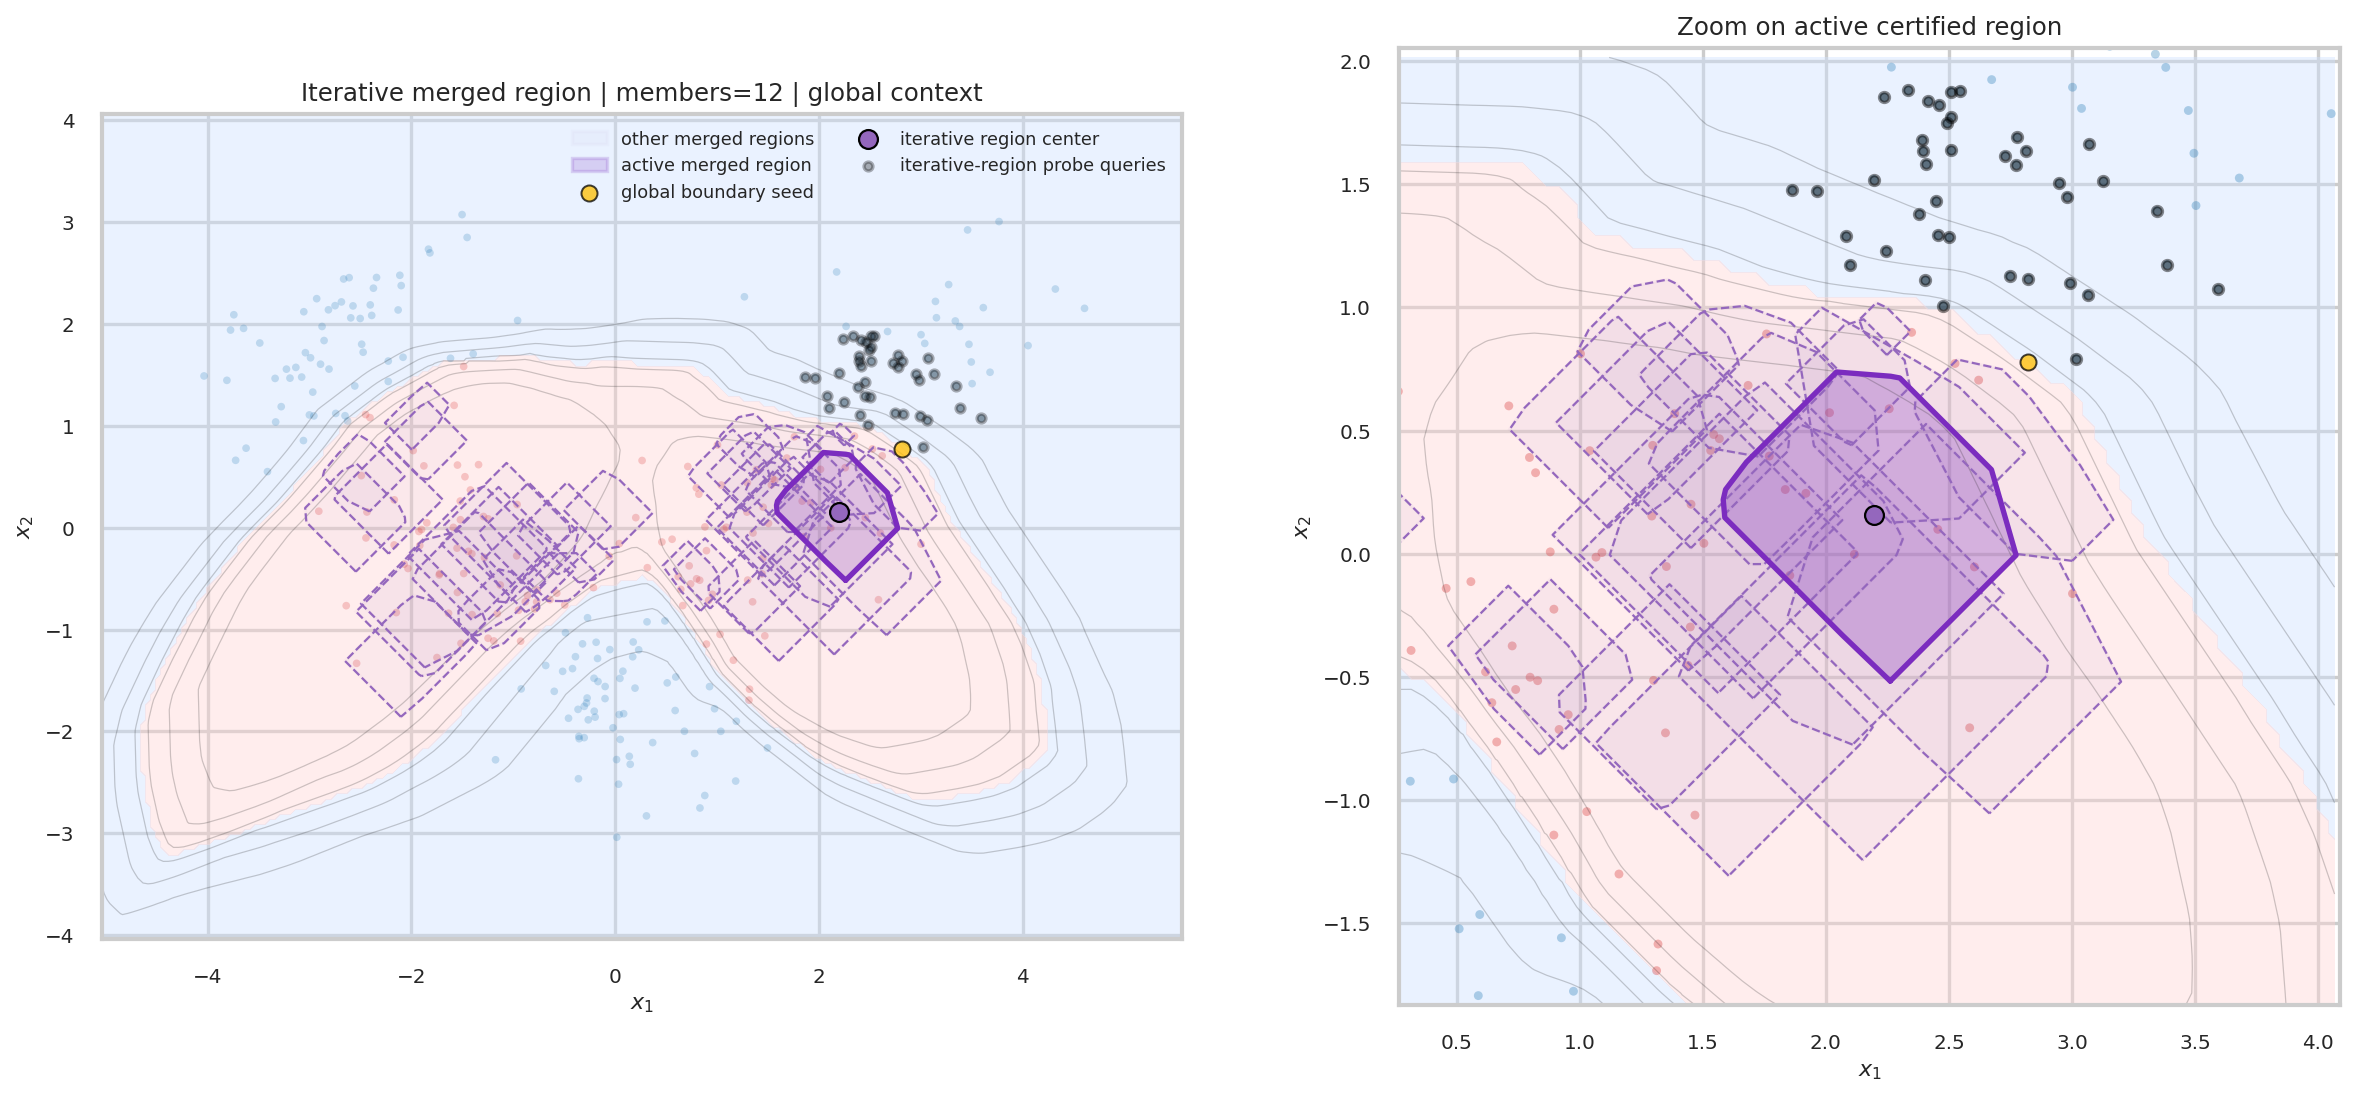

In [7]:
def fill_geom(ax, geom, color, alpha=0.2, label=None, lw=1.2, linestyle='-', xlim=None, ylim=None):
    geoms = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    first = True
    for g in geoms:
        if xlim is not None and ylim is not None:
            minx, miny, maxx, maxy = g.bounds
            if maxx < xlim[0] or minx > xlim[1] or maxy < ylim[0] or miny > ylim[1]:
                continue
        xs, ys = g.exterior.xy
        ax.fill(xs, ys, color=color, alpha=alpha, label=label if first else None)
        ax.plot(xs, ys, color=color, lw=lw, linestyle=linestyle)
        first = False


def draw_decision_background(ax, model, x, y, title, grid_step=0.05, xlim=None, ylim=None):
    x_min = (x[:, 0].min() - 1.0) if xlim is None else xlim[0]
    x_max = (x[:, 0].max() + 1.0) if xlim is None else xlim[1]
    y_min = (x[:, 1].min() - 1.0) if ylim is None else ylim[0]
    y_max = (x[:, 1].max() + 1.0) if ylim is None else ylim[1]
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step), np.arange(y_min, y_max, grid_step))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds, probs = predict_np(model, grid)
    zz = preds.reshape(xx.shape)
    conf = probs.max(axis=1).reshape(xx.shape)
    cmap = ListedColormap(['#cfe2ff', '#ffd6d6'])
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=0.42)
    ax.contour(xx, yy, conf, levels=[0.55, 0.70, 0.85], colors='k', linewidths=0.55, alpha=0.22)
    for cls, color in [(0, '#1f77b4'), (1, '#d62728')]:
        mask = y == cls
        ax.scatter(x[mask, 0], x[mask, 1], s=12 if xlim is None else 16, alpha=0.22 if xlim is None else 0.32, c=color, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)


active_geom = ITER_VIS_REGION['geom'] if ITER_VIS_REGION is not None else VIS['hull']
active_union = ITER_VIS_UNION if ITER_VIS_REGION is not None else VIS['union']
active_center = iter_probe_center if ITER_VIS_REGION is not None else vis_probe_center
active_probe_idx = iter_probe_idx if ITER_VIS_REGION is not None else probe_idx
title_suffix = f'Iterative merged region | members={ITER_VIS_REGION["member_count"]}' if ITER_VIS_REGION is not None else f'Local pair rank={VIS_ROW["pair_rank"]} | {status}'
minx, miny, maxx, maxy = active_geom.bounds
pad = max(maxx - minx, maxy - miny) * 0.85 + 0.25
zoom_xlim = (minx - pad, maxx + pad)
zoom_ylim = (miny - pad, maxy + pad)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.2), dpi=160)
draw_decision_background(axes[0], MODEL, X_TEST, Y_TEST_PRED, title=f'{title_suffix} | global context')
draw_decision_background(axes[1], MODEL, X_TEST, Y_TEST_PRED, title='Zoom on active certified region', xlim=zoom_xlim, ylim=zoom_ylim)

for panel_idx, ax in enumerate(axes):
    xlim = None if panel_idx == 0 else zoom_xlim
    ylim = None if panel_idx == 0 else zoom_ylim

    iterative_regions_to_show = [region for region in ITER_FINAL_REGIONS if int(region['member_count']) > 1]
    for region_idx, region in enumerate(iterative_regions_to_show[:40]):
        if ITER_VIS_REGION is not None and region['region_key'] == ITER_VIS_REGION['region_key']:
            continue
        fill_geom(ax, region['geom'], color='#9467bd', alpha=0.035 if panel_idx == 0 else 0.055, label='other merged regions' if region_idx == 0 and panel_idx == 0 else None, lw=1.0, linestyle='--', xlim=xlim, ylim=ylim)

    if ITER_VIS_REGION is not None:
        fill_geom(ax, ITER_VIS_REGION['geom'], color='#7b2cbf', alpha=0.18 if panel_idx == 0 else 0.28, label='active merged region' if panel_idx == 0 else None, lw=2.4, xlim=xlim, ylim=ylim)

    seed = boundary_seed
    ax.scatter([seed[0]], [seed[1]], c='#ffbf00', s=52, edgecolors='black', linewidths=0.9, alpha=0.75, label='global boundary seed' if panel_idx == 0 else None, zorder=6)
    if ITER_VIS_REGION is not None:
        ax.scatter([iter_probe_center[0]], [iter_probe_center[1]], c='#9467bd', s=72, edgecolors='black', linewidths=1.0, label='iterative region center' if panel_idx == 0 else None, zorder=8)
        ax.scatter(X_TEST[iter_probe_idx, 0], X_TEST[iter_probe_idx, 1], c='black', s=16 if panel_idx == 0 else 20, alpha=0.30 if panel_idx == 0 else 0.45, label='iterative-region probe queries' if panel_idx == 0 else None)
    else:
        ax.scatter(X_TEST[probe_idx, 0], X_TEST[probe_idx, 1], c='black', s=16 if panel_idx == 0 else 20, alpha=0.30 if panel_idx == 0 else 0.45, label='local-pair probe queries' if panel_idx == 0 else None)

axes[0].legend(frameon=False, loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## Questions to ask after running

- Do the best local pairs actually have hull-area ratios close to 1?
- How often do these near-redundant local pairs certify successfully?
- Does the wrapped hull reduce distance for nearby source queries without adding much new area?
- Is the local-pair heuristic strong enough to justify trying triples later?
- If even the best local pairs fail, is merged certification too conservative to be worth pursuing?
